c:\Users\hi6\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
예측 결과:
[[0.00180035]
 [0.9635764 ]
 [0.99970174]]

학습 이력 키:
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


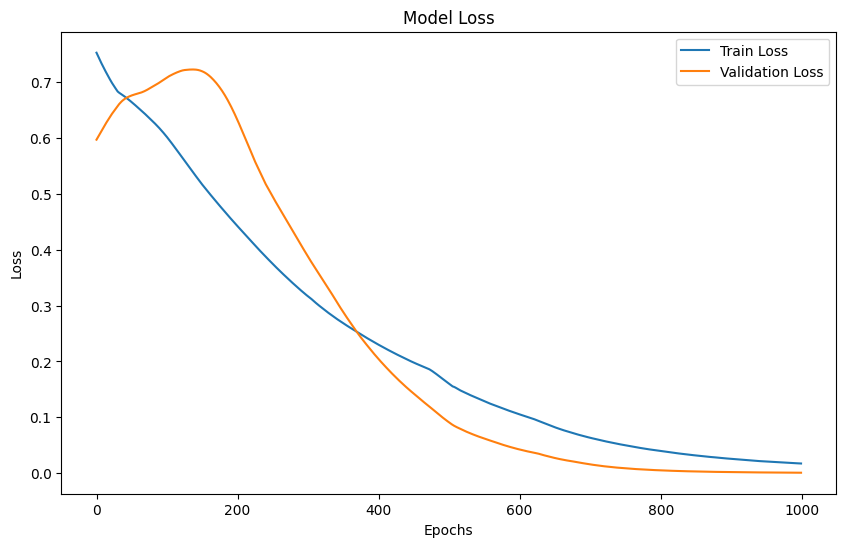

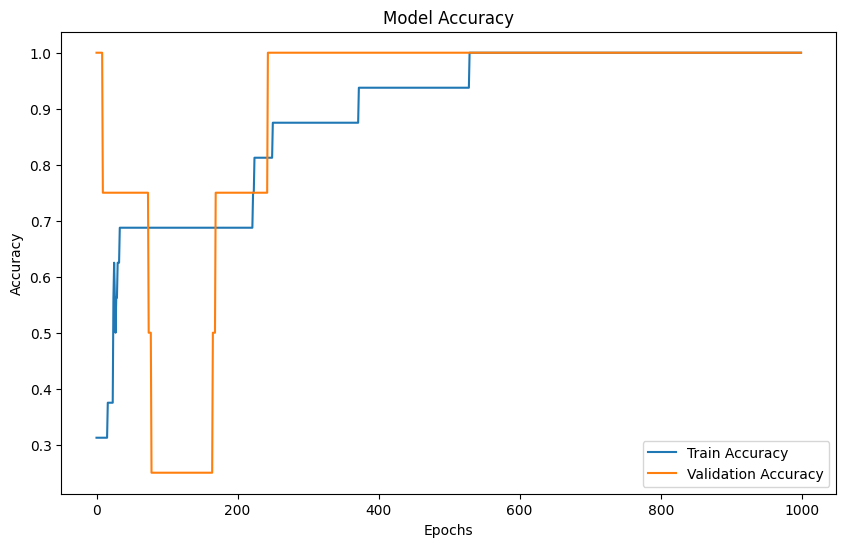

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 데이터 로드
dataset = pd.read_csv('성적데이터.csv')

# 합격/불합격 변환 (pass3 생성)
dataset['pass3'] = np.where(dataset['score'] >= 60, 1, 0)

# 독립변수, 종속변수 분리
X = dataset[['hour','absent']]
y = dataset['pass3']

# 정규화를 해주는 객체
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(X.values)

# 모델 설계
model1 = tf.keras.models.Sequential([
  normalizer,
  tf.keras.layers.Dense(4, activation='relu', input_shape=(2,)),
  tf.keras.layers.Dense(8, activation='relu'),
  tf.keras.layers.Dense(4, activation='relu'),
  tf.keras.layers.Dense(1, activation='sigmoid'),
])

# 모델 컴파일
model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 학습
history = model1.fit(X.values, y.values, epochs=1000, validation_split=0.2, verbose=0)

# 예측
합격여부 = model1.predict(np.array([[5,0],[10,5],[8,1]]))
print("예측 결과:")
print(합격여부)

# 학습 이력 출력
print("\n학습 이력 키:")
print(history.history.keys())

# 손실도 그래프
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 정확도 그래프
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [59]:
# 최종 평가
# 실제 데이터라고 가정
df2 = pd.DataFrame({'hour':[4, 5.5, 8.5, 6],'absent':[0, 3, 3, 0],'pass':[0, 0, 1, 1]})

X_test = df2[['hour','absent']].values
y_test = df2['pass'].values

# reshape 제거 또는 올바르게 수정
test_loss, test_acc = model1.evaluate(X_test, y_test)
print(f'예측 정확도 : {test_acc:.4f}, 오차 : {test_loss:.4f}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.0384
예측 정확도 : 1.0000, 오차 : 0.0384


In [61]:
model1.predict(np.array([[5.5,3],[8.5,3]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


array([[0.13809854],
       [0.9959731 ]], dtype=float32)

In [63]:
# 모델 저장
# 전체 저장
model1.save('my_model.h5')

In [64]:
load_model = tf.keras.models.load_model('my_model.h5')
load_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_7 (Normalization) │ (None, 2)              │             5 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100 (408.00 B)

 Trainable params: 93 (372.00 B)

 Non-trainable params: 5 (24.00 B)

 Optimizer params: 2 (12.00 B)